# Comparing sampling when exact velocity is known

Linear flows
The simplest (and, indeed, very powerful) flow is the linear one, $\varphi t(x, y)=\alpha_t x+\sigma_t y$, giving

$$
X_t=\alpha_t X_0+\sigma_t X_1 .
$$


Here, $\alpha, \sigma$ are differentiable functions and must satisfy the constraint $\alpha 0=\sigma 1=1$ and $\alpha 1=\sigma 0=0$. The trajectories are straight lines going from $X_0$ to $X_1$ at a velocity given by

$$
\dot{X}_t=\dot{\alpha}_t X_0+\dot{\sigma}_t X_1 .
$$§


In the simplest setting, we can simply choose $\alpha_t=1-t$ and $\sigma_t=t$. This is called rectified flows. The velocity is constant, $\dot{X}_t=X_1-X_0$, so that the flow-matching loss minimizes $\mathbb{E}\left[|s(X_t)-(X_1-X_0)|^2\right]$.
"Gaussian" flows
In practice, the goal of (most) generative models is to sample from $p 0$, which leaves open the choice for $p 1$. The natural choice goes for simplicity, with $p 1=N(0, I d)$. In this case, noting $\varepsilon$ instead of $X_1$, the marginals of (13) are exactly the ones we found for the noising process in diffusions. The conditional velocity $v_t(x)=\mathbb{E}[\dot{X}_t \mid X_t=x]$ is simply

$$
v_t(x)=\dot{\alpha}_t \mathbb{E}[X_0 \mid X_t=x]+\dot{\sigma}_t \mathbb{E}[\varepsilon \mid X_t=x] .
$$


Tweedie's formula, as seen in the preceding note on score matching, gives

$$
v_t(x)=\frac{\dot{\alpha}_t}{\alpha_t} x+\sigma_t^2 \nabla \ln p_t(x)\left[\frac{\dot{\alpha}_t}{\alpha_t}-\frac{\dot{\sigma}_t}{\sigma_t}\right] .
$$


Note that $\dot{\alpha}_t / \alpha_t-\dot{\sigma}_t / \sigma_t$ is equal to $\dot{\lambda}_t / 2$, which is half the time-derivative of the lof-SNR (signel-to-noise) ratio $\lambda t=\ln (\alpha \stackrel{2}{t} / \sigma \stackrel{2}{t})$.
Proof. Tweedie's denoising formula says that since $p_t$ is the distribution of $\alpha_t X_0$ noised by $\sigma_t \varepsilon \sim N\left(0, \sigma_t^2 I d\right)$, then

$$
\mathbb{E}\left[\varepsilon \mid X_t\right]=\frac{\mathbb{E}\left[\sigma_{t \varepsilon} \mid X_t\right]}{\sigma_t}=-\sigma_t \nabla \ln p_t\left(X_t\right) .
$$


Similarly,

$$
\mathbb{E}[X_0 \mid X_t]=\frac{X_t+\sigma_t^2 \nabla \ln p_t(X_t)}{\alpha_t}
$$


Gathering the two yields the formula.

Formula (16) tells us (once again!) that the only thing that matters given the choice of $\alpha_t, \sigma_t$ is the knowledge of the score $\nabla \ln p_t$. How this score was learnt is actually an independent problem: we don't care how the learning was done. When we have the score, we can plug it in (16) and sample.

By carefully looking at the derivations, we can see that there are one-to-one linear connections between
- $\nabla \ln p_t$ (the score)
- $\mathbb{E}[\varepsilon \mid X_t]$ (the denoising model)
- $\mathbb{E}[X_0 \mid X_t]$ (the data prediction model)
- $v_t$ (the velocity model).

Only one of them needs to be learned, and we can convert it into the three others. If one wants to use a pretrained model for sampling, one thus needs to keep_track of how the model was learned: is it a score, a denoiser, a data predictor or a velocity?

We close this part with an important note: given a score model for $\nabla \ln p_t$, regardless of how it is formulated and trained, using it to sample from the flow $\dot{x}_t=v_t(X_t)$ or to sample from the DDIM ODE in diffusion models is exactly the same.

With the rectified-flow choice

$$
\alpha_t=1-t, \quad \sigma_t=t,
$$
So the exact velocity becomes

$$
v_t(x)=\frac{1}{t}\left(x-\mu_t(x)\right)
$$

with

$$
\mu_t(x)=\frac{\int_0^{2 \pi} \gamma(\theta) \sqrt{r(\theta)^2+r^{\prime}(\theta)^2} \exp \left(-\frac{\|x-(1-t) \gamma(\theta)\|^2}{2 t^2}\right) d \theta}{\int_0^{2 \pi} \sqrt{r(\theta)^2+r^{\prime}(\theta)^2} \exp \left(-\frac{\|x-(1-t) \gamma(\theta)\|^2}{2 t^2}\right) d \theta}
$$

and

$$
\begin{gathered}
r(\theta)=1+a \sin (n \theta), \quad r^{\prime}(\theta)=a n \cos (n \theta), \\
\gamma(\theta)=(1+a \sin (n \theta))\binom{\cos \theta}{\sin \theta} .
\end{gathered}
$$


So the fully simplified exact velocity field is

$$
v_t(x)=\frac{1}{t}\left[x-\frac{\int_0^{2 \pi} \gamma(\theta) \sqrt{(1+a \sin (n \theta))^2+a^2 n^2 \cos ^2(n \theta)} e^{-\frac{\|x-(1-t) \gamma(\theta)\|^2}{2 t^2}} d \theta}{\int_0^{2 \pi} \sqrt{(1+a \sin (n \theta))^2+a^2 n^2 \cos ^2(n \theta)} e^{-\frac{\|x-(1-t) \gamma(\theta)\|^2}{2 t^2}} d \theta}\right] .
$$


This is the exact rectified-flow velocity for the star-shaped curve distribution.

In [1]:
import os, subprocess, sys

# Ensure all required packages are present
_required = {"scipy": "scipy", "ot": "pot", "sklearn": "scikit-learn"}
for mod, pkg in _required.items():
    try:
        __import__(mod)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

os.makedirs("plots", exist_ok=True)

print("Setup OK.")


Setup OK.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── wiggling-circle config ────────────────────────────────────────────────────
k_values    = [2, 4, 8, 16, 32, 64]   # angular frequencies
a           = 0.125                     # radial amplitude

# ── ellipse config ────────────────────────────────────────────────────────────
b_major  = 1.0
b_minors = [1.0, 0.8, 0.6, 0.4, 0.2, 0.05]

# ── sampling / tracking config ────────────────────────────────────────────────
N_PARTICLES = 1000    # particles for scatter plots
N_STEPS     = 200     # Euler steps
N_THETA     = 512     # quadrature points
N_TARGET    = 2000    # reference samples for W_2
N_PART_W2   = 500     # particles for W_2 / KL tracking
N_SNAP      = 20      # snapshots per integration
SIGMA_TRUE  = 0.01    # noise sigma for KL reference distribution

# ── shared colour palettes ────────────────────────────────────────────────────
colors_target    = plt.cm.viridis(np.linspace(0.0, 1.0, len(k_values)))
colors_samples   = plt.cm.plasma( np.linspace(0.2, 0.9, len(k_values)))
palette          = plt.cm.viridis(np.linspace(0.0, 0.9, len(k_values)))

colors_e_target  = plt.cm.viridis(np.linspace(0.0, 1.0, len(b_minors)))
colors_e_samples = plt.cm.plasma( np.linspace(0.2, 0.9, len(b_minors)))
palette_e        = plt.cm.viridis(np.linspace(0.0, 0.9, len(b_minors)))

ecc_vals = [np.sqrt(1 - (bm / b_major)**2) for bm in b_minors]

print("Config OK.")


Config OK.


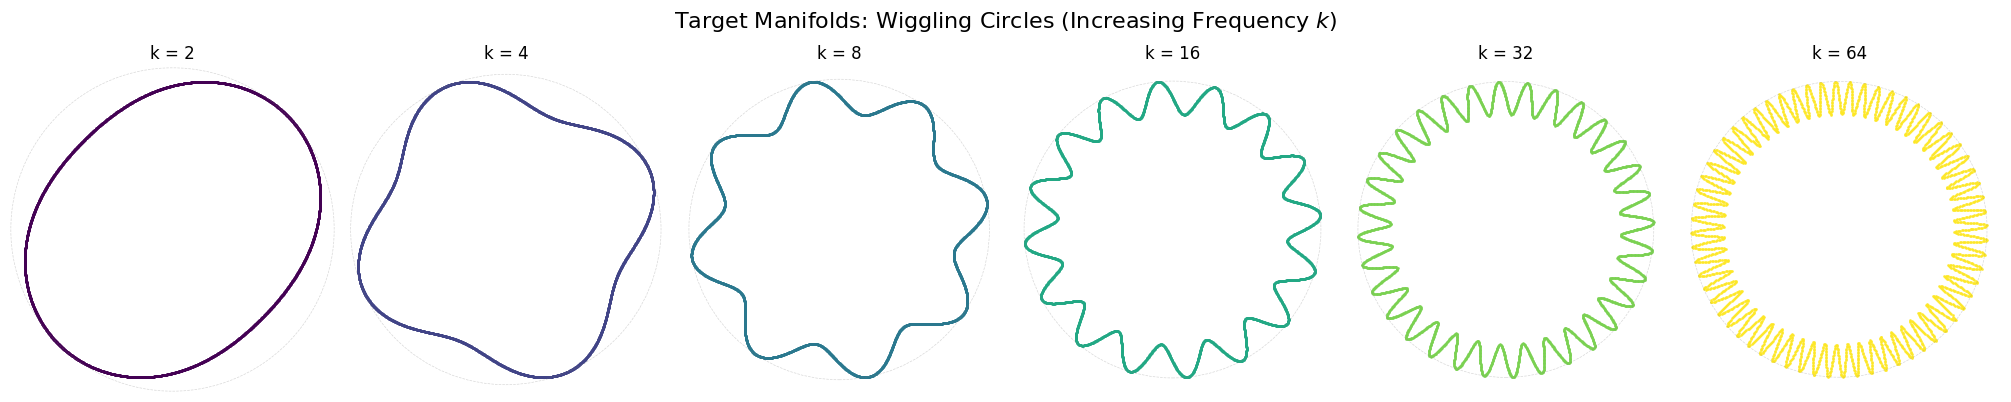

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. Data Generation Function ---
def get_wiggling_curve(k, R=1.0, A=0.125, n_samples=3000):
    """Generates arc-length uniform samples for a wiggling circle."""
    n_fine = 1000
    theta_fine = np.linspace(0, 2 * np.pi, n_fine)
    r = R + A * np.sin(k * theta_fine)
    x_fine = r * np.cos(theta_fine)
    y_fine = r * np.sin(theta_fine)
    
    # Cumulative arc length for uniform sampling
    ds = np.sqrt(np.diff(x_fine)**2 + np.diff(y_fine)**2)
    cumulative_length = np.insert(np.cumsum(ds), 0, 0.0)
    
    length_to_theta = interp1d(cumulative_length, theta_fine, kind='linear')
    sampled_lengths = np.linspace(0, cumulative_length[-1], n_samples)
    theta_uniform = length_to_theta(sampled_lengths)
    
    r_u = R + A * np.sin(k * theta_uniform)
    return r_u * np.cos(theta_uniform), r_u * np.sin(theta_uniform)

# --- 2. Plotting Row ---
colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))

fig, axs = plt.subplots(1, len(k_values), figsize=(20, 4), constrained_layout=True)
fig.suptitle("Target Manifolds: Wiggling Circles (Increasing Frequency $k$)", fontsize=16, y=1.05)

for i, k in enumerate(k_values):
    x, y = get_wiggling_curve(k)
    
    # Plot the curve
    axs[i].scatter(x, y, s=1, color=colors[i], alpha=0.8)
    
    # Formatting
    axs[i].set_title(f"k = {k}")
    axs[i].set_aspect('equal')
    axs[i].axis('off')
    
    # Optional: Add a subtle boundary for scale
    circle = plt.Circle((0, 0), 1.125, color='gray', fill=False, lw=0.5, ls='--', alpha=0.3)
    axs[i].add_patch(circle)

plt.show()

## Exact velocity field & Euler sampler

For rectified flow ($\alpha_t = 1-t$, $\sigma_t = t$) with wiggling-circle target $p_0$:

$$v_t(x) = \frac{x - \mu_t(x)}{t}, \qquad \mu_t(x) = \mathbb{E}[X_0 \mid X_t = x]$$

The posterior mean integrates over the curve with arc-length weighting:

$$\mu_t(x) = \frac{\int_0^{2\pi} \gamma(\theta)\, w(\theta)\, e^{-\|x - (1-t)\gamma(\theta)\|^2 / 2t^2}\, d\theta}{\int_0^{2\pi} w(\theta)\, e^{-\|x - (1-t)\gamma(\theta)\|^2 / 2t^2}\, d\theta}$$

Euler integration runs from $t=1$ (noise $\mathcal{N}(0,I)$) to $t=t_{\min}$ (data).

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


def exact_velocity(x, t, n, a=0.125, N_theta=512):
    """
    Exact rectified-flow velocity for wiggling-circle target.

    x       : (N, 2) particle positions at time t
    t       : scalar in (0, 1]
    n       : angular frequency  (k in data-gen code)
    a       : radial amplitude   (A in data-gen code)
    N_theta : quadrature resolution

    Returns (N, 2) velocity vectors.
    """
    theta = np.linspace(0, 2 * np.pi, N_theta, endpoint=False)

    r  =  1.0 + a * np.sin(n * theta)
    dr =  a * n * np.cos(n * theta)
    w  = np.sqrt(r**2 + dr**2)

    gamma = np.stack([r * np.cos(theta),
                      r * np.sin(theta)], axis=1)   # (T, 2)

    diff    = x[:, None, :] - (1 - t) * gamma[None, :, :]
    sq_dist = np.sum(diff**2, axis=-1)

    log_u = np.log(w)[None, :] - sq_dist / (2 * t**2)
    log_u -= np.max(log_u, axis=1, keepdims=True)
    u = np.exp(log_u)

    Z  = u.sum(axis=1, keepdims=True)
    mu = (u @ gamma) / Z

    return (x - mu) / t


def euler_sample(n, a=0.125, N_particles=1000, N_steps=200,
                 t_start=1.0, t_min=0.01, N_theta=512, seed=0):
    """
    Euler ODE integration: noise t=t_start → data t=t_min.
    Steps are geometrically spaced — smaller near t=0 (data).
    """
    rng = np.random.default_rng(seed)
    x   = rng.standard_normal((N_particles, 2))

    ts = np.geomspace(t_start, t_min, N_steps + 1)

    for i in range(N_steps):
        t  = ts[i]
        dt = ts[i + 1] - ts[i]          # dt < 0
        x  = x + dt * exact_velocity(x, t, n, a=a, N_theta=N_theta)

    return x


print("Functions defined.")


Functions defined.


In [5]:
print("Running Euler sampling for each k …")
samples = {}
for k in k_values:
    samples[k] = euler_sample(n=k, a=a,
                              N_particles=N_PARTICLES,
                              N_steps=N_STEPS,
                              N_theta=N_THETA,
                              seed=42)
    print(f"  k={k:3d}  done")
print("All done.")


Running Euler sampling for each k …
  k=  2  done
  k=  4  done
  k=  8  done
  k= 16  done
  k= 32  done
  k= 64  done
All done.


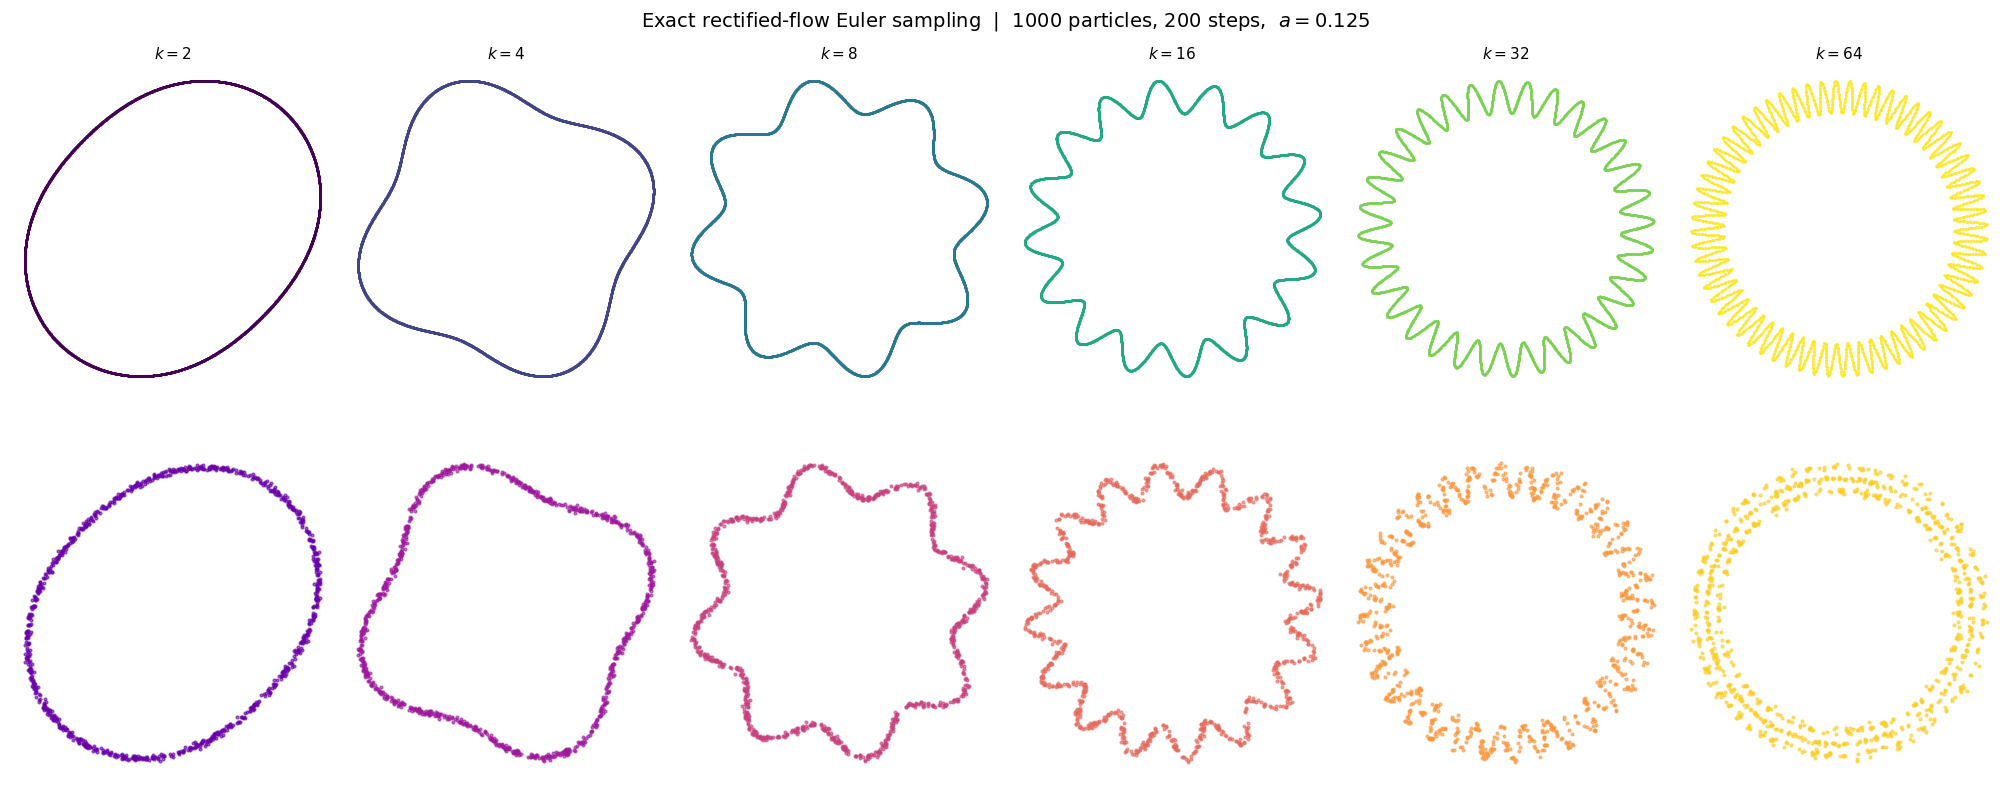

In [6]:
fig, axs = plt.subplots(2, len(k_values), figsize=(20, 8), constrained_layout=True)
fig.suptitle(
    f"Exact rectified-flow Euler sampling  |  "
    f"{N_PARTICLES} particles, {N_STEPS} steps,  $a={a}$",
    fontsize=14,
)

for col, k in enumerate(k_values):
    # ── row 0: target curve ──────────────────────────────────────────────
    tx, ty = get_wiggling_curve(k, A=a, n_samples=3000)
    axs[0, col].scatter(tx, ty, s=1, color=colors_target[col], alpha=0.8)
    axs[0, col].set_title(f"$k={k}$", fontsize=11)
    axs[0, col].set_aspect("equal")
    axs[0, col].axis("off")

    # ── row 1: Euler samples ─────────────────────────────────────────────
    sx, sy = samples[k][:, 0], samples[k][:, 1]
    axs[1, col].scatter(sx, sy, s=4, color=colors_samples[col], alpha=0.6)
    axs[1, col].set_aspect("equal")
    axs[1, col].axis("off")

axs[0, 0].set_ylabel("Target", fontsize=11, labelpad=4)
axs[1, 0].set_ylabel("Euler samples", fontsize=11, labelpad=4)
for ax in axs.flat:
    ax.set_ylabel(ax.get_ylabel(), visible=True)

plt.savefig("plots/06-exact-flowmatching.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
import ot  # POT: Python Optimal Transport


def w2(x, y):
    """W_2 distance between two (N, 2) point clouds (uniform weights)."""
    n, m = len(x), len(y)
    a = np.ones(n) / n
    b = np.ones(m) / m
    M = ot.dist(x, y, metric='sqeuclidean')
    return np.sqrt(ot.emd2(a, b, M))


def euler_sample_tracked(n, a=0.125, N_particles=500, N_steps=200,
                          t_start=1.0, t_min=0.01, N_theta=512,
                          n_snapshots=50, seed=42):
    """
    Euler integration (geometric steps) with particle snapshots.

    Returns
    -------
    ts_snap  : (n_snapshots,) array of t values (descending, 1 → t_min)
    snaps    : list of (N_particles, 2) arrays, one per snapshot
    """
    rng  = np.random.default_rng(seed)
    x    = rng.standard_normal((N_particles, 2))

    ts        = np.geomspace(t_start, t_min, N_steps + 1)
    snap_idxs = set(np.linspace(0, N_steps, n_snapshots, dtype=int))

    ts_snap, snaps = [], []

    for i in range(N_steps):
        if i in snap_idxs:
            ts_snap.append(ts[i])
            snaps.append(x.copy())
        t  = ts[i]
        dt = ts[i + 1] - ts[i]
        x  = x + dt * exact_velocity(x, t, n, a=a, N_theta=N_theta)

    ts_snap.append(ts[-1])
    snaps.append(x.copy())

    return np.array(ts_snap), snaps


print("Tracking function defined.")


Tracking function defined.


In [8]:
print("Running tracked Euler + computing W_2 …")
w2_results = {}   # k → (ts_snap, w2_vals)

for k in k_values:
    # Reference samples from target curve
    tx, ty = get_wiggling_curve(k, A=a, n_samples=N_TARGET)
    target = np.stack([tx, ty], axis=1)

    ts_snap, snaps = euler_sample_tracked(
        n=k, a=a,
        N_particles=N_PART_W2,
        N_steps=200,
        N_theta=N_THETA,
        n_snapshots=N_SNAP,
        seed=42,
    )

    w2_vals = np.array([w2(snap, target) for snap in snaps])
    w2_results[k] = (ts_snap, w2_vals)
    print(f"  k={k:3d}  W_2(t=1)={w2_vals[0]:.3f}  W_2(t_min)={w2_vals[-1]:.3f}")

print("Done.")


Running tracked Euler + computing W_2 …
  k=  2  W_2(t=1)=0.689  W_2(t_min)=0.059
  k=  4  W_2(t=1)=0.682  W_2(t_min)=0.077
  k=  8  W_2(t=1)=0.655  W_2(t_min)=0.081
  k= 16  W_2(t=1)=0.644  W_2(t_min)=0.096
  k= 32  W_2(t=1)=0.644  W_2(t_min)=0.085
  k= 64  W_2(t=1)=0.645  W_2(t_min)=0.078
Done.


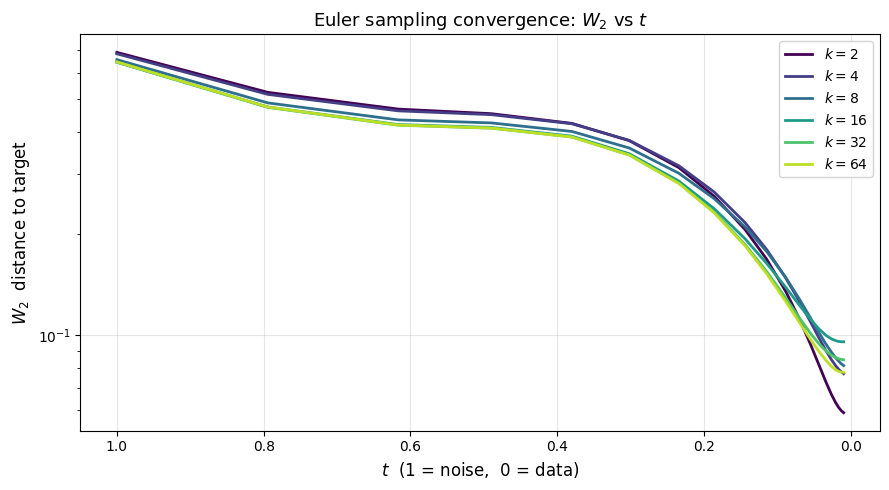

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

for col, k in enumerate(k_values):
    ts_snap, w2_vals = w2_results[k]
    ax.plot(ts_snap, w2_vals, color=palette[col], lw=2, label=f"$k={k}$")

ax.invert_xaxis()
ax.set_yscale("log")
ax.set_xlabel("$t$  (1 = noise,  0 = data)", fontsize=12)
ax.set_ylabel("$W_2$  distance to target", fontsize=12)
ax.set_title("Euler sampling convergence: $W_2$ vs $t$", fontsize=13)
ax.legend(framealpha=0.85, fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/06-w2-convergence.png", dpi=150, bbox_inches="tight")
plt.show()


## Variance Preserving (VP) Flows

In the Variance Preserving (VP) formulation, we add a specific geometric constraint to the interpolation functions $\alpha_t$ and $\sigma_t$. We require that the total variance of the marginal distribution $X_t$ remains constant (equal to $1$) across all time steps, assuming the data $X_0$ is normalized to have unit variance and $X_1 \sim \mathcal{N}(0, I)$. 

To preserve variance, the coefficients must satisfy the algebraic constraint:

$$ \alpha_t^2 + \sigma_t^2 = 1 $$

### Parameterization via Trigonometric Functions
A natural and elegant way to satisfy both this constraint and the boundary conditions ($\alpha_0=1, \sigma_0=0$ and $\alpha_1=0, \sigma_1=1$) is to parameterize the trajectory using trigonometric functions. Let $\theta_t$ be a monotonically increasing function of time running from $0$ to $\frac{\pi}{2}$. We can define:

$$ \alpha_t = \cos(\theta_t), \quad \sigma_t = \sin(\theta_t) $$

In the simplest VP flow setting, we choose a linear schedule for the angle, $\theta_t = \frac{\pi}{2}t$, which yields:

$$ X_t = \cos\left(\frac{\pi}{2}t\right) X_0 + \sin\left(\frac{\pi}{2}t\right) X_1 $$

Unlike standard rectified flows where trajectories are straight lines in Euclidean space, VP flows can be interpreted as moving along a **spherical arc** (or great circle) between the data point and the noise point, preserving the norm of the state vector.

---

## Velocity and the VP Conditional Vector Field

To compute the velocity $\dot{X}_t$, we take the time derivatives of our coefficients:

$$ \dot{\alpha}_t = -\frac{\pi}{2}\sin\left(\frac{\pi}{2}t\right) = -\frac{\pi}{2}\sigma_t $$
$$ \dot{\sigma}_t = \frac{\pi}{2}\cos\left(\frac{\pi}{2}t\right) = \frac{\pi}{2}\alpha_t $$

Substituting these into the conditional velocity formula $v_t(x) = \dot{\alpha}_t \mathbb{E}[X_0 \mid X_t=x] + \dot{\sigma}_t \mathbb{E}[\varepsilon \mid X_t=x]$ yields the explicit VP conditional velocity:

$$ v_t(x) = \frac{\pi}{2} \left( -\sigma_t \mathbb{E}[X_0 \mid X_t=x] + \alpha_t \mathbb{E}[\varepsilon \mid X_t=x] \right) $$

---

## Connecting VP Flows to the Score (Tweedie's Formula)

Using Tweedie's formula exactly as stated in your original notes, we can substitute the VP constraints into the general velocity equation. 

Let's look at the log-SNR term $\lambda_t = \ln(\alpha_t^2 / \sigma_t^2)$ for the VP case:

$$ \lambda_t = \ln\left(\frac{\cos^2(\theta_t)}{\sin^2(\theta_t)}\right) = 2\ln(\cot(\theta_t)) $$

Its time derivative simplifies beautifully due to the variance-preserving constraint. Let's apply the general formula directly:

$$ v_t(x) = \frac{\dot{\alpha}_t}{\alpha_t} x + \sigma_t^2 \nabla \ln p_t(x) \left[ \frac{\dot{\alpha}_t}{\alpha_t} - \frac{\dot{\sigma}_t}{\sigma_t} \right] $$

Substituting $\frac{\dot{\alpha}_t}{\alpha_t} = -\frac{\pi}{2}\tan(\theta_t)$ and $\frac{\dot{\sigma}_t}{\sigma_t} = \frac{\pi}{2}\cot(\theta_t)$:

$$ v_t(x) = -\frac{\pi}{2}\tan(\theta_t)x - \frac{\pi}{2}\sin^2(\theta_t)\left[\tan(\theta_t) + \cot(\theta_t)\right] \nabla \ln p_t(x) $$

Using the trigonometric identity $\tan(\theta) + \cot(\theta) = \frac{1}{\sin(\theta)\cos(\theta)}$, the score coefficient simplifies:

$$ \sin^2(\theta_t) \left[ \frac{1}{\sin(\theta_t)\cos(\theta_t)} \right] = \frac{\sin(\theta_t)}{\cos(\theta_t)} = \tan(\theta_t) $$

Thus, the velocity field for a Variance Preserving Flow Match simplifies to:

$$ v_t(x) = -\frac{\pi}{2}\tan\left(\frac{\pi}{2}t\right) x - \frac{\pi}{2}\tan\left(\frac{\pi}{2}t\right) \nabla \ln p_t(x) $$

> **Note on the VP-ODE Link:** This exact velocity formula perfectly matches the deterministic DDIM / Probability Flow ODE derived from standard VP SDEs (like DDPM), proving once again that the probability trajectories match identically, but the flow matching formulation arrives there via straightforward linear interpolation on a hypersphere.

---

## The Four-Way Dictionary for VP Models

Just like in the general case, you can train a neural network to predict any of the 4 core targets. Because $\alpha_t^2 + \sigma_t^2 = 1$, the algebraic conversions between them become incredibly clean:

| Target Model | Expression in terms of Velocity $v_t(x)$ |
| :--- | :--- |
| **Velocity Model** $v_t(x)$ | $v_t(x)$ |
| **Score Model** $\nabla \ln p_t(x)$ | $-\frac{2}{\pi}\cot(\theta_t)v_t(x) - x$ |
| **Denoising Model** $\mathbb{E}[\varepsilon \mid X_t]$ | $\sigma_t x + \frac{2}{\pi}\alpha_t v_t(x)$ |
| **Data Prediction Model** $\mathbb{E}[X_0 \mid X_t]$ | $\alpha_t x - \frac{2}{\pi}\sigma_t v_t(x)$ |

If you are using a model pretrained on a traditional VP diffusion setup (which typically predicts the noise $\varepsilon$), you can instantly convert it into a VP velocity field for ODE sampling using the relation:

$$ v_t(x) = \frac{\pi}{2} \left( \alpha_t \epsilon_\theta(x, t) - \sigma_t x \right) $$

## VP flow: exact velocity, Euler sampler, W₂ convergence

In [10]:
def exact_velocity_vp(x, t, n, a=0.125, N_theta=512):
    """
    Exact VP-flow velocity for wiggling-circle target.

    alpha_t = cos(pi*t/2),  sigma_t = sin(pi*t/2)
    X_t | X_0 ~ N(alpha_t * X_0, sigma_t^2 * I)

    v_t(x) = (pi / (2*sigma_t)) * (alpha_t * x - mu_t(x))
    where mu_t(x) = E[X_0 | X_t = x]
    """
    alpha = np.cos(np.pi * t / 2)
    sigma = np.sin(np.pi * t / 2)

    theta = np.linspace(0, 2 * np.pi, N_theta, endpoint=False)

    r  = 1.0 + a * np.sin(n * theta)
    dr = a * n * np.cos(n * theta)
    w  = np.sqrt(r**2 + dr**2)

    gamma = np.stack([r * np.cos(theta),
                      r * np.sin(theta)], axis=1)   # (T, 2)

    # kernel: exp(-||x - alpha*gamma||^2 / (2*sigma^2))
    diff    = x[:, None, :] - alpha * gamma[None, :, :]
    sq_dist = np.sum(diff**2, axis=-1)

    log_u = np.log(w)[None, :] - sq_dist / (2 * sigma**2)
    log_u -= np.max(log_u, axis=1, keepdims=True)
    u = np.exp(log_u)

    Z  = u.sum(axis=1, keepdims=True)
    mu = (u @ gamma) / Z                             # E[X_0 | X_t=x]

    return (np.pi / (2 * sigma)) * (alpha * x - mu)


def euler_sample_vp(n, a=0.125, N_particles=1000, N_steps=200,
                    t_start=1.0, t_min=0.01, N_theta=512, seed=0):
    """
    Euler ODE integration for VP flow: noise t=t_start → data t=t_min.
    Geometric time steps — smaller near t=0 (data).
    """
    rng = np.random.default_rng(seed)
    x   = rng.standard_normal((N_particles, 2))

    ts = np.geomspace(t_start, t_min, N_steps + 1)

    for i in range(N_steps):
        t  = ts[i]
        dt = ts[i + 1] - ts[i]
        x  = x + dt * exact_velocity_vp(x, t, n, a=a, N_theta=N_theta)

    return x


def euler_sample_tracked_vp(n, a=0.125, N_particles=500, N_steps=200,
                             t_start=1.0, t_min=0.01, N_theta=512,
                             n_snapshots=20, seed=42):
    """VP-flow Euler integration with particle snapshots."""
    rng  = np.random.default_rng(seed)
    x    = rng.standard_normal((N_particles, 2))

    ts        = np.geomspace(t_start, t_min, N_steps + 1)
    snap_idxs = set(np.linspace(0, N_steps, n_snapshots, dtype=int))

    ts_snap, snaps = [], []

    for i in range(N_steps):
        if i in snap_idxs:
            ts_snap.append(ts[i])
            snaps.append(x.copy())
        t  = ts[i]
        dt = ts[i + 1] - ts[i]
        x  = x + dt * exact_velocity_vp(x, t, n, a=a, N_theta=N_theta)

    ts_snap.append(ts[-1])
    snaps.append(x.copy())

    return np.array(ts_snap), snaps


print("VP functions defined.")


VP functions defined.


In [11]:
print("Running VP Euler sampling …")
samples_vp = {}
for k in k_values:
    samples_vp[k] = euler_sample_vp(n=k, a=a,
                                    N_particles=N_PARTICLES,
                                    N_steps=N_STEPS,
                                    N_theta=N_THETA,
                                    seed=42)
    print(f"  k={k:3d}  done")
print("All done.")


Running VP Euler sampling …
  k=  2  done
  k=  4  done
  k=  8  done
  k= 16  done
  k= 32  done
  k= 64  done
All done.


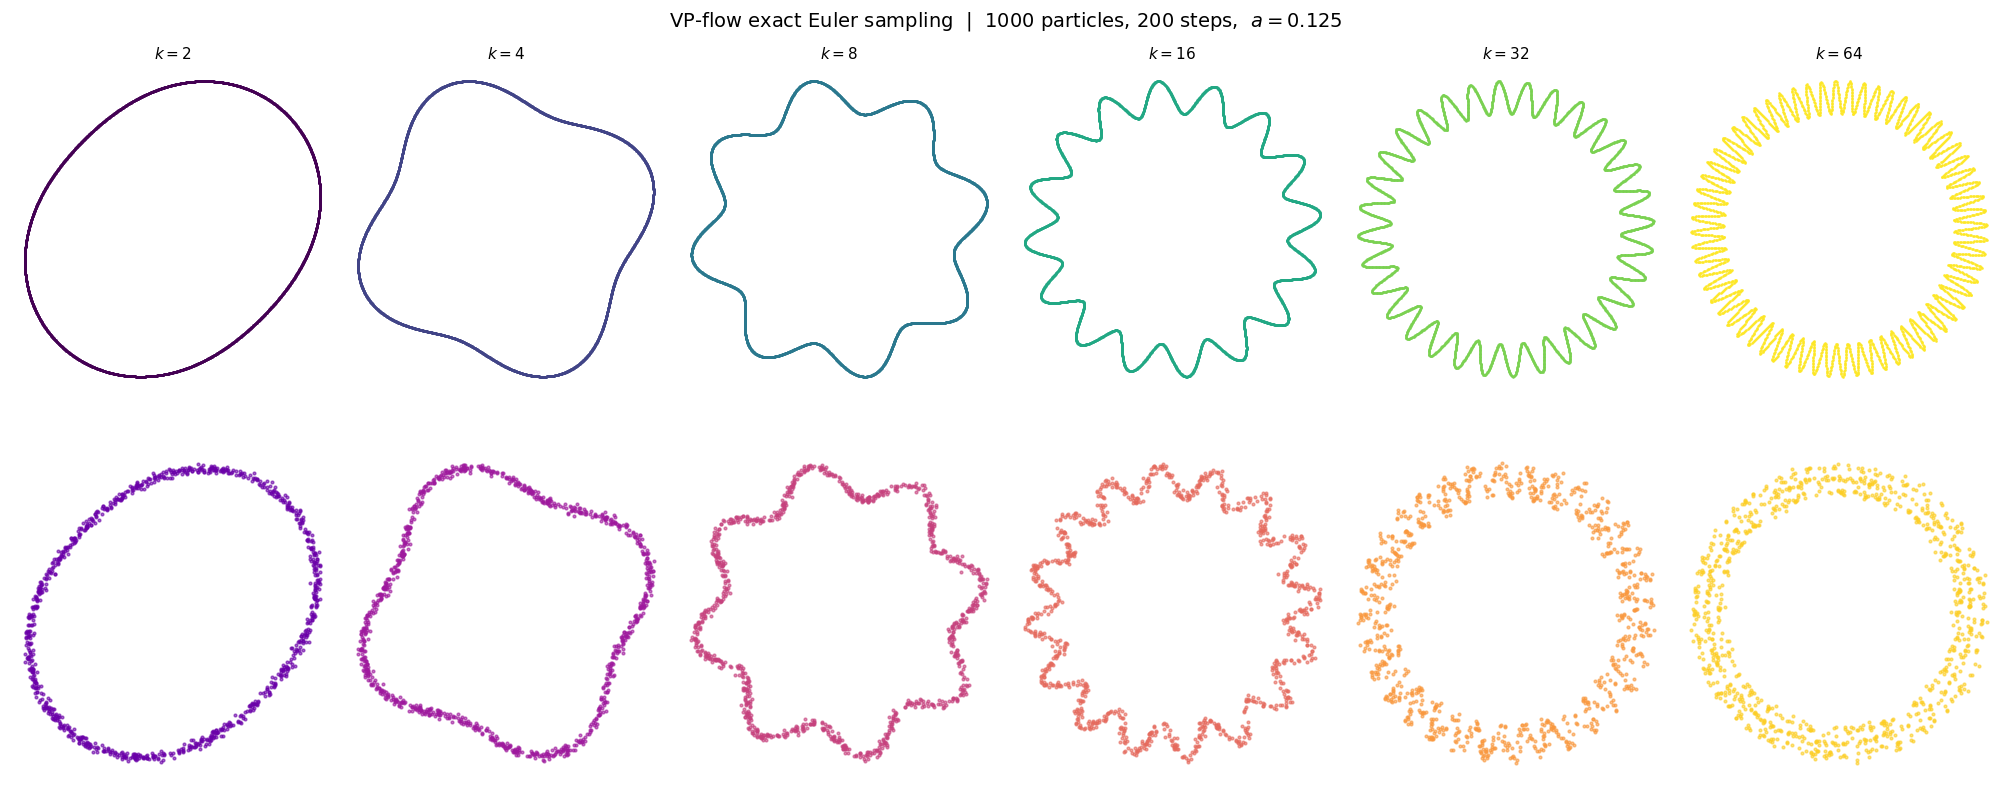

In [12]:
fig, axs = plt.subplots(2, len(k_values), figsize=(20, 8), constrained_layout=True)
fig.suptitle(
    f"VP-flow exact Euler sampling  |  "
    f"{N_PARTICLES} particles, {N_STEPS} steps,  $a={a}$",
    fontsize=14,
)

for col, k in enumerate(k_values):
    tx, ty = get_wiggling_curve(k, A=a, n_samples=3000)
    axs[0, col].scatter(tx, ty, s=1, color=colors_target[col], alpha=0.8)
    axs[0, col].set_title(f"$k={k}$", fontsize=11)
    axs[0, col].set_aspect("equal")
    axs[0, col].axis("off")

    sx, sy = samples_vp[k][:, 0], samples_vp[k][:, 1]
    axs[1, col].scatter(sx, sy, s=4, color=colors_samples[col], alpha=0.6)
    axs[1, col].set_aspect("equal")
    axs[1, col].axis("off")

axs[0, 0].set_ylabel("Target", fontsize=11)
axs[1, 0].set_ylabel("VP Euler samples", fontsize=11)

plt.savefig("plots/06-vp-exact-flowmatching.png", dpi=150, bbox_inches="tight")
plt.show()


In [13]:
print("Running VP tracked Euler + computing W_2 …")
w2_results_vp = {}

for k in k_values:
    tx, ty = get_wiggling_curve(k, A=a, n_samples=N_TARGET)
    target = np.stack([tx, ty], axis=1)

    ts_snap, snaps = euler_sample_tracked_vp(
        n=k, a=a,
        N_particles=N_PART_W2,
        N_steps=200,
        N_theta=N_THETA,
        n_snapshots=N_SNAP,
        seed=42,
    )

    w2_vals = np.array([w2(snap, target) for snap in snaps])
    w2_results_vp[k] = (ts_snap, w2_vals)
    print(f"  k={k:3d}  W_2(t=1)={w2_vals[0]:.3f}  W_2(t_min)={w2_vals[-1]:.3f}")

print("Done.")


Running VP tracked Euler + computing W_2 …
  k=  2  W_2(t=1)=0.689  W_2(t_min)=0.063
  k=  4  W_2(t=1)=0.682  W_2(t_min)=0.077
  k=  8  W_2(t=1)=0.655  W_2(t_min)=0.081
  k= 16  W_2(t=1)=0.644  W_2(t_min)=0.094
  k= 32  W_2(t=1)=0.644  W_2(t_min)=0.083
  k= 64  W_2(t=1)=0.645  W_2(t_min)=0.076
Done.


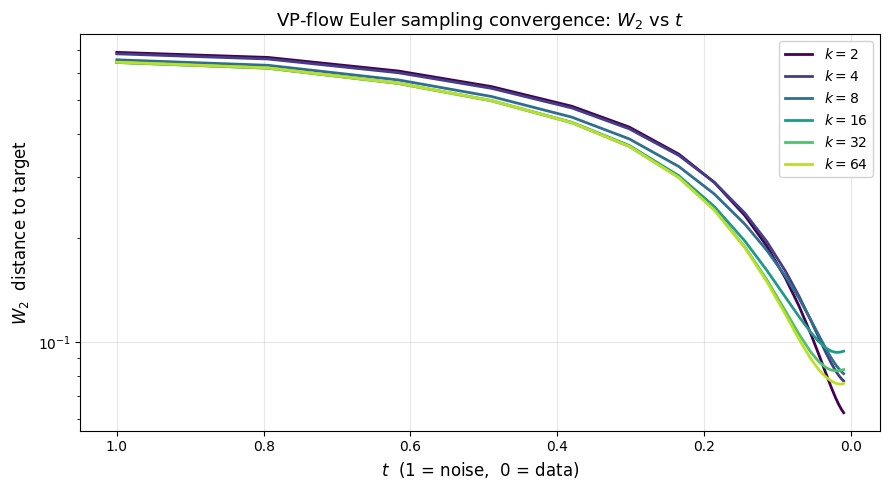

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

for col, k in enumerate(k_values):
    ts_snap, w2_vals = w2_results_vp[k]
    ax.plot(ts_snap, w2_vals, color=palette[col], lw=2, label=f"$k={k}$")

ax.invert_xaxis()
ax.set_yscale("log")
ax.set_xlabel("$t$  (1 = noise,  0 = data)", fontsize=12)
ax.set_ylabel("$W_2$  distance to target", fontsize=12)
ax.set_title("VP-flow Euler sampling convergence: $W_2$ vs $t$", fontsize=13)
ax.legend(framealpha=0.85, fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/06-vp-w2-convergence.png", dpi=150, bbox_inches="tight")
plt.show()


In [15]:
from sklearn.neighbors import KDTree


def sample_true(k, a=0.125, N=500, seed=0):
    """Samples from the true distribution: curve + Gaussian noise N(0, sigma^2 I)."""
    rng = np.random.default_rng(seed)
    x, y = get_wiggling_curve(k, A=a, n_samples=N)
    pts  = np.stack([x, y], axis=1)
    return pts + rng.normal(0, SIGMA_TRUE, pts.shape)


def kl_knn(p_samples, q_samples, k=5):
    """
    KL(P || Q) via k-NN estimator (Wang-Kulkarni-Verdú 2009).

    d/n * sum_i log(nu_k(x_i) / rho_k(x_i)) + log(m / (n-1))

    rho_k : k-th NN distance of x_i within P (leave-one-out)
    nu_k  : k-th NN distance of x_i within Q
    """
    d = p_samples.shape[1]
    n = len(p_samples)
    m = len(q_samples)

    tree_p = KDTree(p_samples)
    tree_q = KDTree(q_samples)

    # k-th NN in P excluding self → ask for k+1, drop index 0 (self, dist=0)
    rho = tree_p.query(p_samples, k=k + 1)[0][:, k]   # k-th neighbor
    nu  = tree_q.query(p_samples, k=k    )[0][:, k-1]  # k-th neighbor

    # clip to avoid log(0)
    rho = np.maximum(rho, 1e-10)
    nu  = np.maximum(nu,  1e-10)

    return d * np.mean(np.log(nu / rho)) + np.log(m / (n - 1))


print("KL estimator defined.")


KL estimator defined.


In [16]:
print("Running tracked Euler + computing KL (RF and VP) …")
kl_results_rf = {}
kl_results_vp = {}

for k in k_values:
    p_true = sample_true(k, a=a, N=N_PART_W2, seed=0)

    # --- Rectified flow ---
    ts_rf, snaps_rf = euler_sample_tracked(
        n=k, a=a, N_particles=N_PART_W2, N_steps=200,
        N_theta=N_THETA, n_snapshots=N_SNAP, seed=42,
    )
    kl_rf = np.array([kl_knn(p_true, snap) for snap in snaps_rf])
    kl_results_rf[k] = (ts_rf, kl_rf)

    # --- VP flow ---
    ts_vp, snaps_vp = euler_sample_tracked_vp(
        n=k, a=a, N_particles=N_PART_W2, N_steps=200,
        N_theta=N_THETA, n_snapshots=N_SNAP, seed=42,
    )
    kl_vp = np.array([kl_knn(p_true, snap) for snap in snaps_vp])
    kl_results_vp[k] = (ts_vp, kl_vp)

    print(f"  k={k:3d}  RF KL(t=1)={kl_rf[0]:.2f}  KL(t_min)={kl_rf[-1]:.3f}"
          f"  |  VP KL(t=1)={kl_vp[0]:.2f}  KL(t_min)={kl_vp[-1]:.3f}")

print("Done.")


Running tracked Euler + computing KL (RF and VP) …
  k=  2  RF KL(t=1)=2.96  KL(t_min)=-0.171  |  VP KL(t=1)=2.96  KL(t_min)=-0.111
  k=  4  RF KL(t=1)=2.92  KL(t_min)=-0.171  |  VP KL(t=1)=2.92  KL(t_min)=-0.096
  k=  8  RF KL(t=1)=2.67  KL(t_min)=-0.190  |  VP KL(t=1)=2.67  KL(t_min)=-0.099
  k= 16  RF KL(t=1)=2.16  KL(t_min)=-0.267  |  VP KL(t=1)=2.16  KL(t_min)=-0.210
  k= 32  RF KL(t=1)=1.55  KL(t_min)=-0.239  |  VP KL(t=1)=1.55  KL(t_min)=-0.223
  k= 64  RF KL(t=1)=1.43  KL(t_min)=-0.168  |  VP KL(t=1)=1.43  KL(t_min)=-0.176
Done.


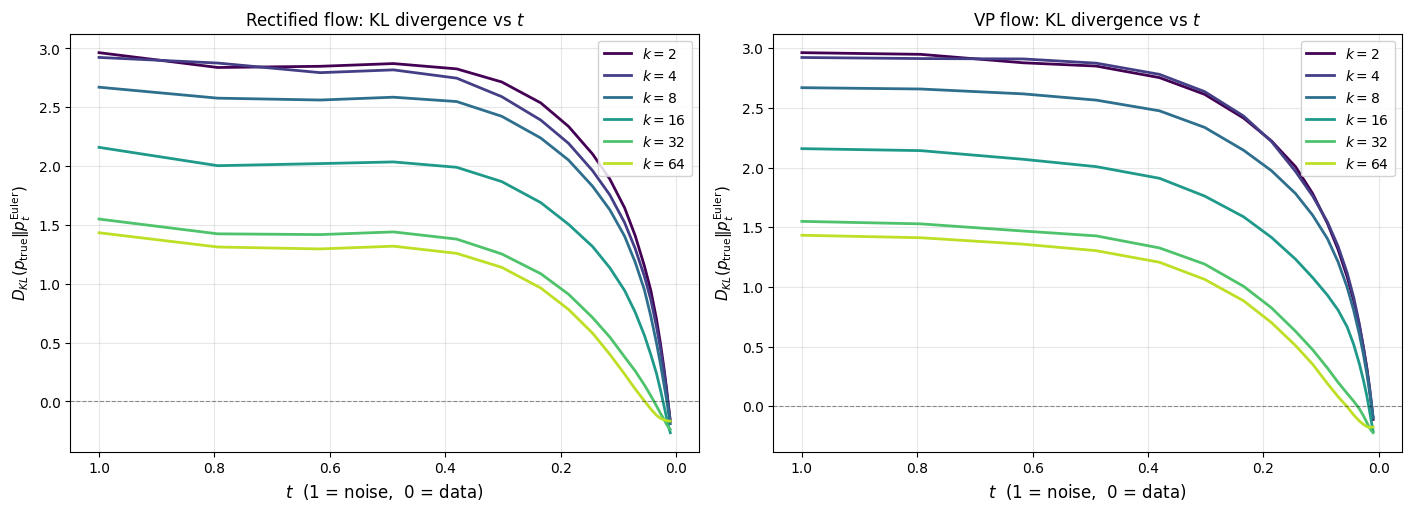

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, (results, title) in zip(axes, [
    (kl_results_rf, "Rectified flow"),
    (kl_results_vp, "VP flow"),
]):
    for col, k in enumerate(k_values):
        ts, kl_vals = results[k]
        ax.plot(ts, kl_vals, color=palette[col], lw=2, label=f"$k={k}$")

    ax.invert_xaxis()
    ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.4)
    ax.set_xlabel("$t$  (1 = noise,  0 = data)", fontsize=12)
    ax.set_ylabel(r"$D_{KL}(p_{\mathrm{true}} \| p_t^{\mathrm{Euler}})$", fontsize=11)
    ax.set_title(f"{title}: KL divergence vs $t$", fontsize=12)
    ax.legend(framealpha=0.85, fontsize=10)
    ax.grid(True, alpha=0.3)

plt.savefig("plots/06-kl-convergence.png", dpi=150, bbox_inches="tight")
plt.show()


## Ellipses

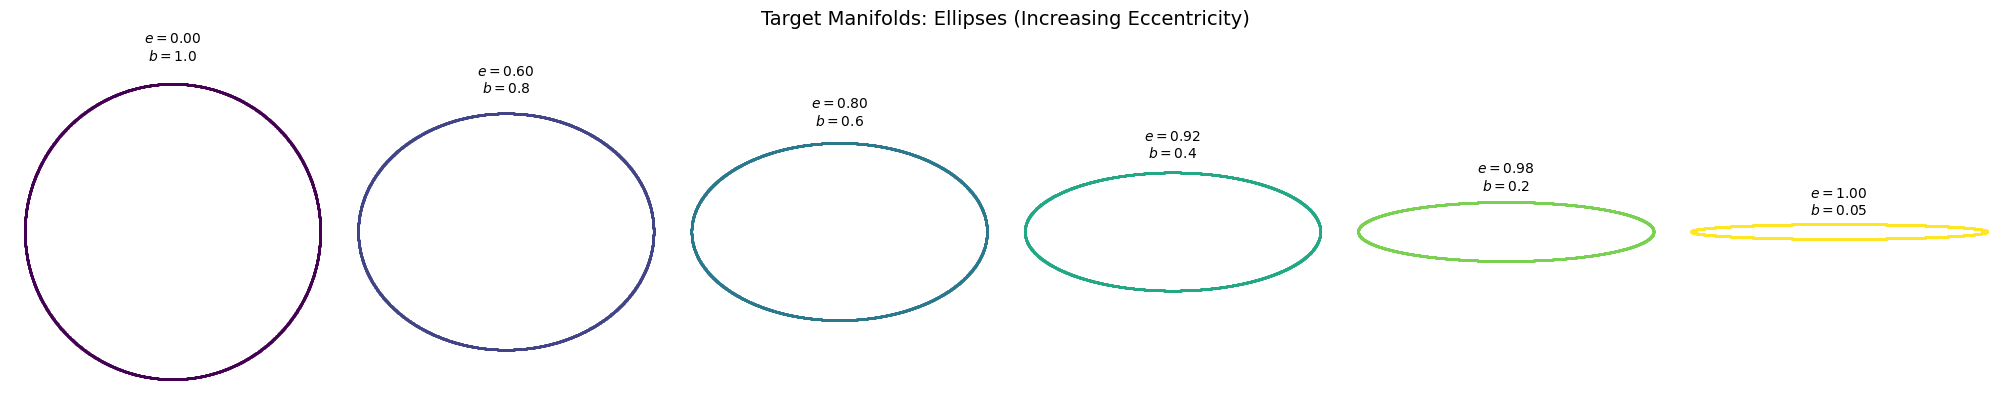

In [18]:
def get_ellipse(b, a=1.0, n_samples=3000, n_fine=2000):
    """Arc-length uniform samples from ellipse with semi-axes (a, b)."""
    theta_fine = np.linspace(0, 2 * np.pi, n_fine, endpoint=False)
    x_fine = a * np.cos(theta_fine)
    y_fine = b * np.sin(theta_fine)

    ds = np.sqrt(np.diff(x_fine, append=x_fine[0])**2 +
                 np.diff(y_fine, append=y_fine[0])**2)
    cumlen = np.insert(np.cumsum(ds), 0, 0.0)
    # close the curve
    cumlen_closed = np.append(cumlen[:-1], cumlen[-1])

    from scipy.interpolate import interp1d
    t2theta = interp1d(cumlen[:-1], theta_fine, kind='linear')
    sampled = np.linspace(0, cumlen[-2], n_samples, endpoint=False)
    theta_u = t2theta(sampled)

    return a * np.cos(theta_u), b * np.sin(theta_u)


def ellipse_geometry(b, a=1.0, N_theta=512):
    """Returns (gamma, w): quadrature points and arc-length weights."""
    theta = np.linspace(0, 2 * np.pi, N_theta, endpoint=False)
    gamma = np.stack([a * np.cos(theta), b * np.sin(theta)], axis=1)
    # ||gamma'(theta)|| = sqrt(a^2 sin^2 + b^2 cos^2)
    w = np.sqrt(a**2 * np.sin(theta)**2 + b**2 * np.cos(theta)**2)
    return gamma, w


fig, axs = plt.subplots(1, len(b_minors), figsize=(20, 4), constrained_layout=True)
fig.suptitle("Target Manifolds: Ellipses (Increasing Eccentricity)", fontsize=14, y=1.05)

for i, (bm, e) in enumerate(zip(b_minors, ecc_vals)):
    x, y = get_ellipse(bm, a=b_major, n_samples=3000)
    axs[i].scatter(x, y, s=1, color=colors_e_target[i], alpha=0.8)
    axs[i].set_title(f"$e={e:.2f}$\n$b={bm}$", fontsize=10)
    axs[i].set_aspect("equal")
    axs[i].axis("off")

plt.show()


     b       e         L       tau   L/sqrt(tau)
  1.00   0.000    6.2826  1.000000        6.2826
  0.80   0.600    5.6718  0.640000        7.0898
  0.60   0.800    5.1050  0.360000        8.5084
  0.40   0.917    4.6024  0.160000       11.5059
  0.20   0.980    4.2019  0.040000       21.0094
  0.05   0.999    4.0194  0.002500       80.3879


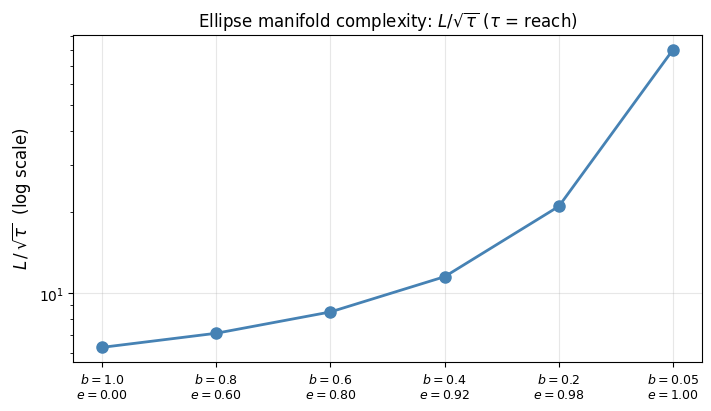

In [24]:
def ellipse_reach(b, a=1.0):
    """Reach = min radius of curvature = b^2/a (achieved at major-axis tips)."""
    return b**2 / a

def ellipse_circumference(b, a=1.0, N=10_000):
    """Arc-length of ellipse via trapezoidal quadrature."""
    theta = np.linspace(0, 2 * np.pi, N, endpoint=False)
    w = np.sqrt(a**2 * np.sin(theta)**2 + b**2 * np.cos(theta)**2)
    return np.trapezoid(w, theta)

reaches        = np.array([ellipse_reach(bm, a=b_major)        for bm in b_minors])
circumferences = np.array([ellipse_circumference(bm, a=b_major) for bm in b_minors])
ratios         = circumferences / np.sqrt(reaches)

print(f"{'b':>6}  {'e':>6}  {'L':>8}  {'tau':>8}  {'L/sqrt(tau)':>12}")
for bm, e, L, tau, r in zip(b_minors, ecc_vals, circumferences, reaches, ratios):
    print(f"{bm:6.2f}  {e:6.3f}  {L:8.4f}  {tau:8.6f}  {r:12.4f}")

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)

ax.plot(range(len(b_minors)), ratios, "o-", color="steelblue", lw=2, ms=8)
ax.set_yscale("log")
ax.set_xticks(range(len(b_minors)))
ax.set_xticklabels(
    [f"$b={bm}$\n$e={e:.2f}$" for bm, e in zip(b_minors, ecc_vals)],
    fontsize=9,
)
ax.set_ylabel(r"$L \,/\, \sqrt{\tau}$  (log scale)", fontsize=12)
ax.set_title(
    r"Ellipse manifold complexity: $L/\sqrt{\tau}$ ($\tau$ = reach)", fontsize=12
)
ax.grid(True, alpha=0.3)

plt.savefig("plots/06-ellipse-complexity.png", dpi=150, bbox_inches="tight")
plt.show()


In [19]:
def exact_velocity_rf_ellipse(x, t, b, a=1.0, N_theta=512):
    """Exact rectified-flow velocity for ellipse target. v_t = (x - mu_t) / t"""
    gamma, w = ellipse_geometry(b, a=a, N_theta=N_theta)

    diff    = x[:, None, :] - (1 - t) * gamma[None, :, :]
    sq_dist = np.sum(diff**2, axis=-1)

    log_u = np.log(w)[None, :] - sq_dist / (2 * t**2)
    log_u -= np.max(log_u, axis=1, keepdims=True)
    u = np.exp(log_u)

    mu = (u @ gamma) / u.sum(axis=1, keepdims=True)
    return (x - mu) / t


def exact_velocity_vp_ellipse(x, t, b, a=1.0, N_theta=512):
    """Exact VP-flow velocity for ellipse target. v_t = pi/(2*sigma) * (alpha*x - mu_t)"""
    alpha = np.cos(np.pi * t / 2)
    sigma = np.sin(np.pi * t / 2)
    gamma, w = ellipse_geometry(b, a=a, N_theta=N_theta)

    diff    = x[:, None, :] - alpha * gamma[None, :, :]
    sq_dist = np.sum(diff**2, axis=-1)

    log_u = np.log(w)[None, :] - sq_dist / (2 * sigma**2)
    log_u -= np.max(log_u, axis=1, keepdims=True)
    u = np.exp(log_u)

    mu = (u @ gamma) / u.sum(axis=1, keepdims=True)
    return (np.pi / (2 * sigma)) * (alpha * x - mu)


def euler_ellipse(velocity_fn, b, a=1.0, N_particles=1000, N_steps=200,
                  t_start=1.0, t_min=0.01, N_theta=512, seed=0):
    """Euler sampler for an ellipse using the given velocity function."""
    rng = np.random.default_rng(seed)
    x   = rng.standard_normal((N_particles, 2))
    ts  = np.geomspace(t_start, t_min, N_steps + 1)
    for i in range(N_steps):
        t  = ts[i]
        dt = ts[i + 1] - ts[i]
        x  = x + dt * velocity_fn(x, t, b, a=a, N_theta=N_theta)
    return x


def euler_ellipse_tracked(velocity_fn, b, a=1.0, N_particles=500, N_steps=200,
                           t_start=1.0, t_min=0.01, N_theta=512,
                           n_snapshots=20, seed=42):
    """Euler sampler with snapshots."""
    rng  = np.random.default_rng(seed)
    x    = rng.standard_normal((N_particles, 2))
    ts   = np.geomspace(t_start, t_min, N_steps + 1)
    snap_idxs = set(np.linspace(0, N_steps, n_snapshots, dtype=int))
    ts_snap, snaps = [], []
    for i in range(N_steps):
        if i in snap_idxs:
            ts_snap.append(ts[i]); snaps.append(x.copy())
        x = x + (ts[i+1] - ts[i]) * velocity_fn(x, ts[i], b, a=a, N_theta=N_theta)
    ts_snap.append(ts[-1]); snaps.append(x.copy())
    return np.array(ts_snap), snaps


print("Ellipse velocity functions defined.")


Ellipse velocity functions defined.


In [20]:
print("Euler sampling ellipses (RF + VP) …")
samp_rf_e, samp_vp_e = {}, {}
for bm in b_minors:
    samp_rf_e[bm] = euler_ellipse(exact_velocity_rf_ellipse, bm, a=b_major,
                                   N_particles=N_PARTICLES, N_steps=N_STEPS,
                                   N_theta=N_THETA, seed=42)
    samp_vp_e[bm] = euler_ellipse(exact_velocity_vp_ellipse, bm, a=b_major,
                                   N_particles=N_PARTICLES, N_steps=N_STEPS,
                                   N_theta=N_THETA, seed=42)
    print(f"  b={bm:.2f}  done")
print("Done.")


Euler sampling ellipses (RF + VP) …
  b=1.00  done
  b=0.80  done
  b=0.60  done
  b=0.40  done
  b=0.20  done
  b=0.05  done
Done.


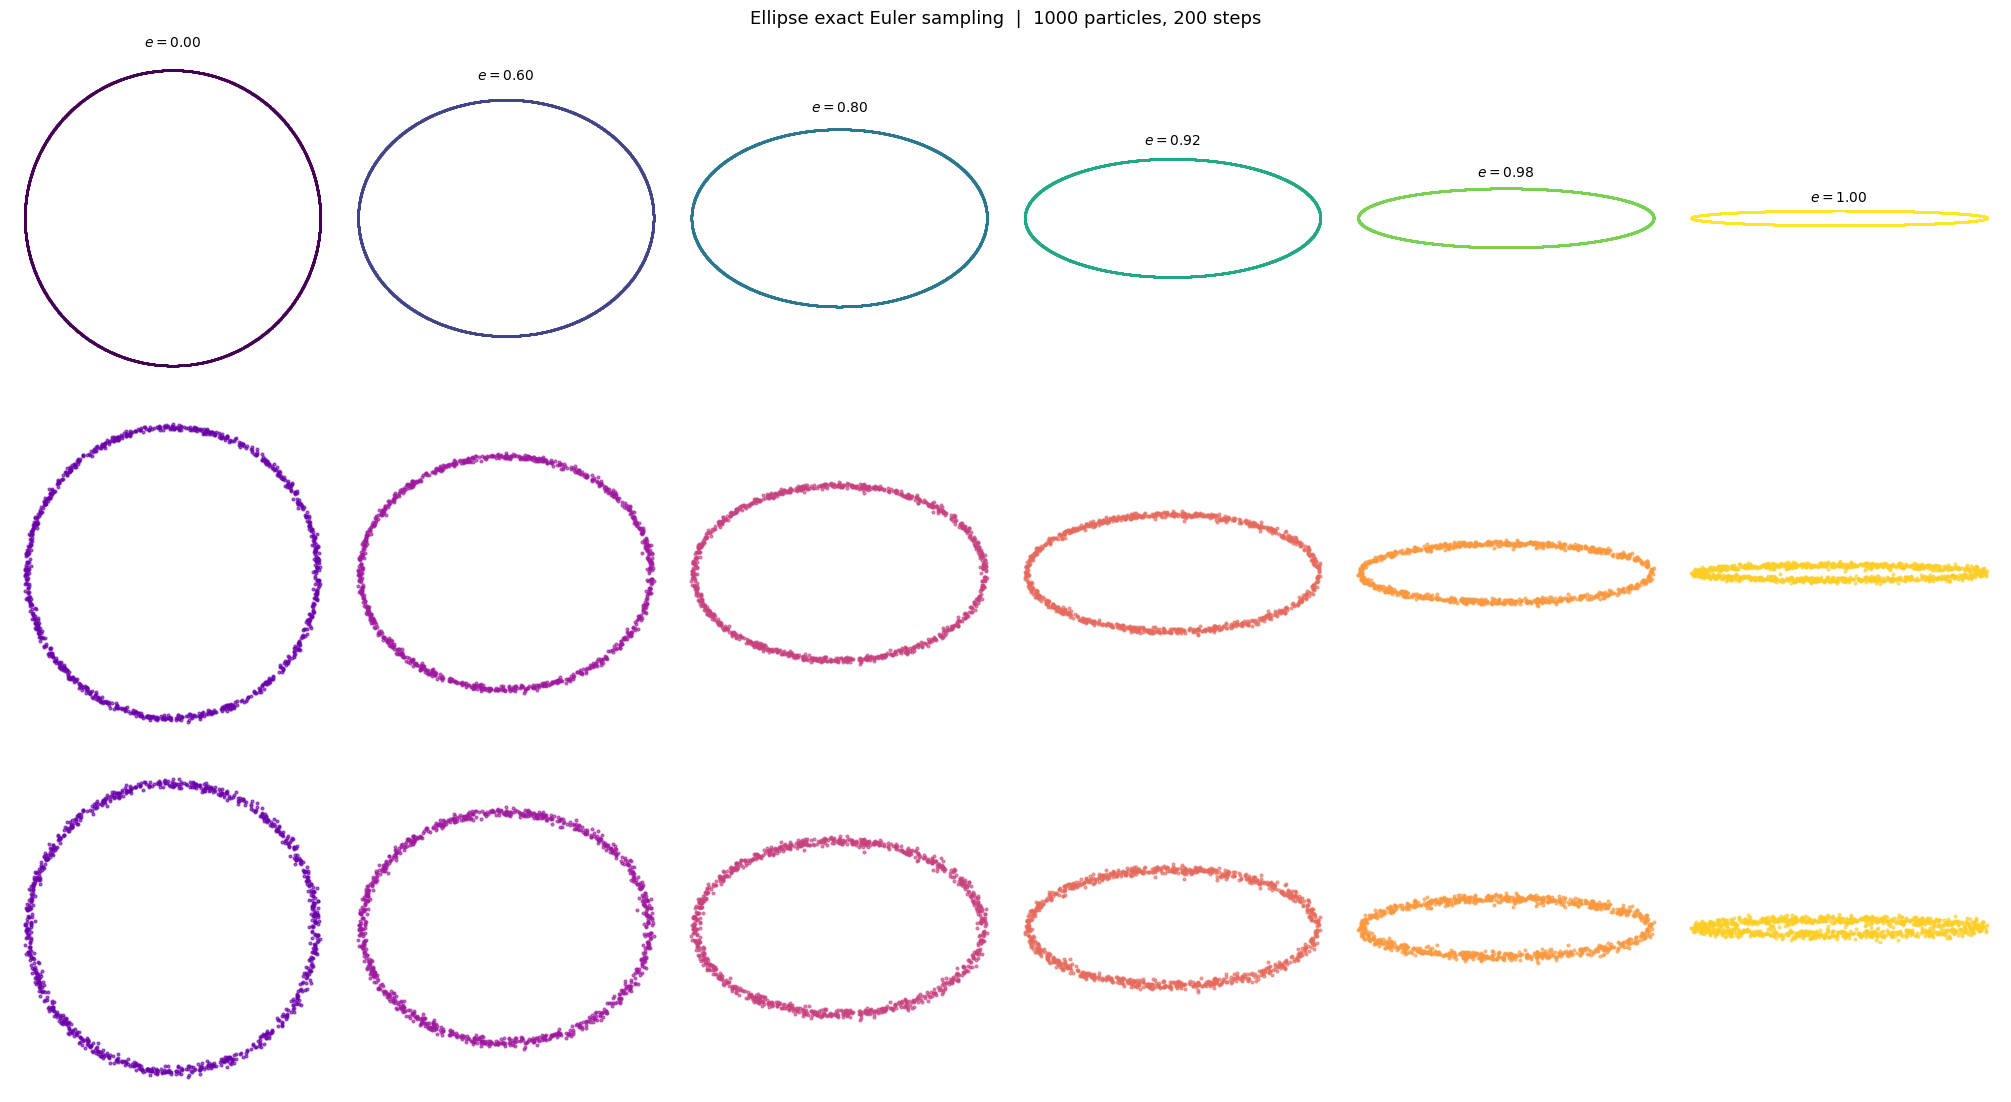

In [21]:
fig, axs = plt.subplots(3, len(b_minors), figsize=(20, 11), constrained_layout=True)
fig.suptitle(f"Ellipse exact Euler sampling  |  {N_PARTICLES} particles, {N_STEPS} steps", fontsize=13)

for col, bm in enumerate(b_minors):
    e = ecc_vals[col]

    tx, ty = get_ellipse(bm, a=b_major, n_samples=3000)
    axs[0, col].scatter(tx, ty, s=1, color=colors_e_target[col], alpha=0.8)
    axs[0, col].set_title(f"$e={e:.2f}$", fontsize=10)

    for row, samp in enumerate([samp_rf_e, samp_vp_e], start=1):
        sx, sy = samp[bm][:, 0], samp[bm][:, 1]
        axs[row, col].scatter(sx, sy, s=4, color=colors_e_samples[col], alpha=0.6)

    for row in range(3):
        axs[row, col].set_aspect("equal"); axs[row, col].axis("off")

axs[0, 0].set_ylabel("Target",         fontsize=10)
axs[1, 0].set_ylabel("RF samples",     fontsize=10)
axs[2, 0].set_ylabel("VP samples",     fontsize=10)

plt.savefig("plots/06-ellipse-sampling.png", dpi=150, bbox_inches="tight")
plt.show()


In [22]:
print("W_2 tracking (ellipses, RF + VP) …")
w2_rf_e, w2_vp_e = {}, {}

for bm in b_minors:
    tx, ty = get_ellipse(bm, a=b_major, n_samples=N_TARGET)
    target = np.stack([tx, ty], axis=1)

    ts_rf, snaps_rf = euler_ellipse_tracked(exact_velocity_rf_ellipse, bm, a=b_major,
                                             N_particles=N_PART_W2, N_steps=200,
                                             N_theta=N_THETA, n_snapshots=N_SNAP, seed=42)
    ts_vp, snaps_vp = euler_ellipse_tracked(exact_velocity_vp_ellipse, bm, a=b_major,
                                             N_particles=N_PART_W2, N_steps=200,
                                             N_theta=N_THETA, n_snapshots=N_SNAP, seed=42)

    w2_rf_e[bm] = (ts_rf, np.array([w2(s, target) for s in snaps_rf]))
    w2_vp_e[bm] = (ts_vp, np.array([w2(s, target) for s in snaps_vp]))
    print(f"  b={bm:.2f}  RF W2_min={w2_rf_e[bm][1][-1]:.3f}  VP W2_min={w2_vp_e[bm][1][-1]:.3f}")

print("Done.")


W_2 tracking (ellipses, RF + VP) …
  b=1.00  RF W2_min=0.066  VP W2_min=0.066
  b=0.80  RF W2_min=0.063  VP W2_min=0.063
  b=0.60  RF W2_min=0.060  VP W2_min=0.059
  b=0.40  RF W2_min=0.057  VP W2_min=0.056
  b=0.20  RF W2_min=0.055  VP W2_min=0.053
  b=0.05  RF W2_min=0.033  VP W2_min=0.030
Done.


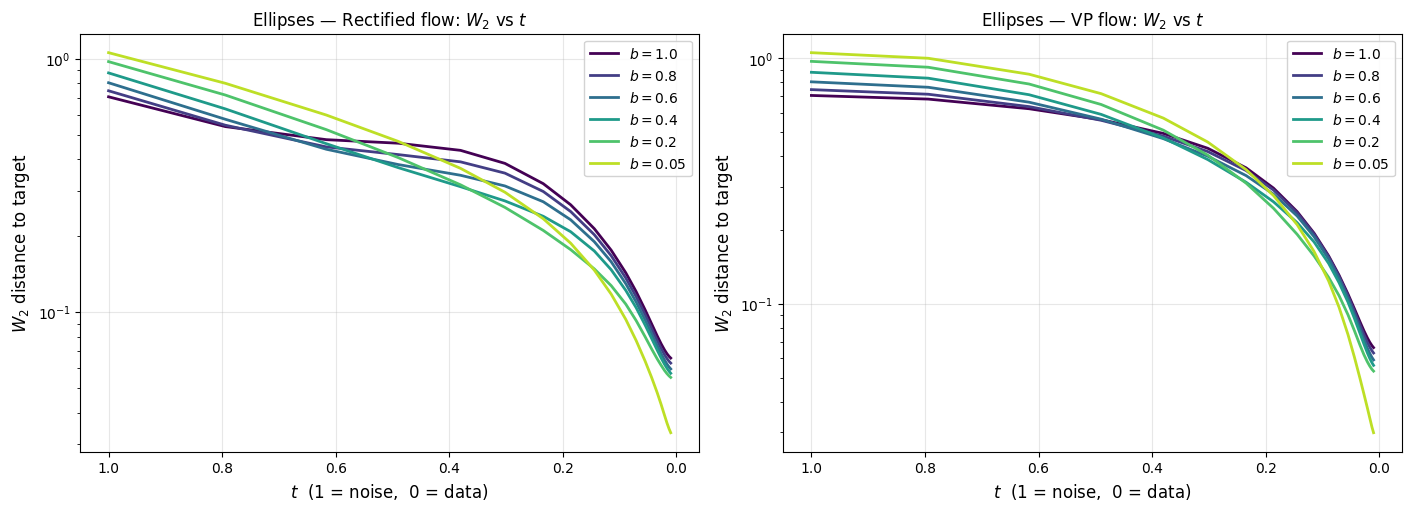

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, (results, title) in zip(axes, [(w2_rf_e, "Rectified flow"), (w2_vp_e, "VP flow")]):
    for col, bm in enumerate(b_minors):
        ts, vals = results[bm]
        ax.plot(ts, vals, color=palette_e[col], lw=2, label=f"$b={bm}$")
    ax.invert_xaxis()
    ax.set_yscale("log")
    ax.set_xlabel("$t$  (1 = noise,  0 = data)", fontsize=12)
    ax.set_ylabel("$W_2$ distance to target", fontsize=12)
    ax.set_title(f"Ellipses — {title}: $W_2$ vs $t$", fontsize=12)
    ax.legend(framealpha=0.85, fontsize=10)
    ax.grid(True, alpha=0.3)

plt.savefig("plots/06-ellipse-w2.png", dpi=150, bbox_inches="tight")
plt.show()


In [24]:
def sample_true_ellipse(b, a=1.0, N=500, seed=0):
    """Samples from ellipse + Gaussian noise N(0, sigma^2 I), sigma=0.01."""
    rng = np.random.default_rng(seed)
    x, y = get_ellipse(b, a=a, n_samples=N)
    pts  = np.stack([x, y], axis=1)
    return pts + rng.normal(0, SIGMA_TRUE, pts.shape)


print("KL tracking (ellipses, RF + VP) …")
kl_rf_e, kl_vp_e = {}, {}

for bm in b_minors:
    p_true = sample_true_ellipse(bm, a=b_major, N=N_PART_W2, seed=0)

    ts_rf, snaps_rf = euler_ellipse_tracked(exact_velocity_rf_ellipse, bm, a=b_major,
                                             N_particles=N_PART_W2, N_steps=200,
                                             N_theta=N_THETA, n_snapshots=N_SNAP, seed=42)
    ts_vp, snaps_vp = euler_ellipse_tracked(exact_velocity_vp_ellipse, bm, a=b_major,
                                             N_particles=N_PART_W2, N_steps=200,
                                             N_theta=N_THETA, n_snapshots=N_SNAP, seed=42)

    kl_rf_e[bm] = (ts_rf, np.array([kl_knn(p_true, s) for s in snaps_rf]))
    kl_vp_e[bm] = (ts_vp, np.array([kl_knn(p_true, s) for s in snaps_vp]))
    print(f"  b={bm:.2f}  RF KL_min={kl_rf_e[bm][1][-1]:.3f}  VP KL_min={kl_vp_e[bm][1][-1]:.3f}")

print("Done.")


KL tracking (ellipses, RF + VP) …
  b=1.00  RF KL_min=-0.165  VP KL_min=-0.123
  b=0.80  RF KL_min=-0.139  VP KL_min=-0.071
  b=0.60  RF KL_min=-0.162  VP KL_min=-0.031
  b=0.40  RF KL_min=-0.108  VP KL_min=0.021
  b=0.20  RF KL_min=-0.156  VP KL_min=0.030
  b=0.05  RF KL_min=-0.124  VP KL_min=0.068
Done.


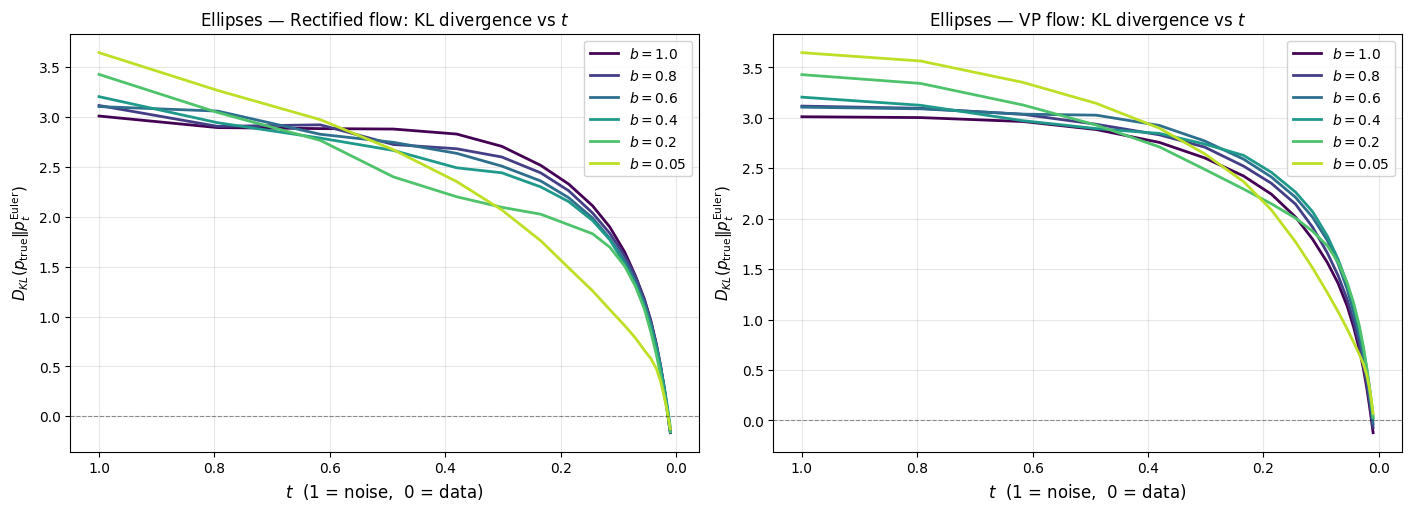

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, (results, title) in zip(axes, [(kl_rf_e, "Rectified flow"), (kl_vp_e, "VP flow")]):
    for col, bm in enumerate(b_minors):
        ts, vals = results[bm]
        ax.plot(ts, vals, color=palette_e[col], lw=2, label=f"$b={bm}$")
    ax.invert_xaxis()
    ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.4)
    ax.set_xlabel("$t$  (1 = noise,  0 = data)", fontsize=12)
    ax.set_ylabel(r"$D_{KL}(p_{\mathrm{true}} \| p_t^{\mathrm{Euler}})$", fontsize=11)
    ax.set_title(f"Ellipses — {title}: KL divergence vs $t$", fontsize=12)
    ax.legend(framealpha=0.85, fontsize=10)
    ax.grid(True, alpha=0.3)

plt.savefig("plots/06-ellipse-kl.png", dpi=150, bbox_inches="tight")
plt.show()
